# Comparison to QGIS output

This notebook compares the square vs. hex grid results of the Python analysis, with the GIS dataset.

In [40]:
# Imports
import rasterio
import rasterio.plot
from rasterio.windows import Window
import geopandas as gpd
from rasterio.mask import mask
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import pearsonr

In [41]:
# Load park boundaries
park_gdf = gpd.read_file("../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
print(f"Park CRS: {park_gdf.crs}")
park_gdf.head()

Park CRS: EPSG:4326


,Park Name,Primary Name,Park Segment Name,geometry
0,Woodhouse Moor,Woodhouse Moor,Woodhouse Moor,"POLYGON ((-1.56424 53.80949, -1.56554 53.80992..."


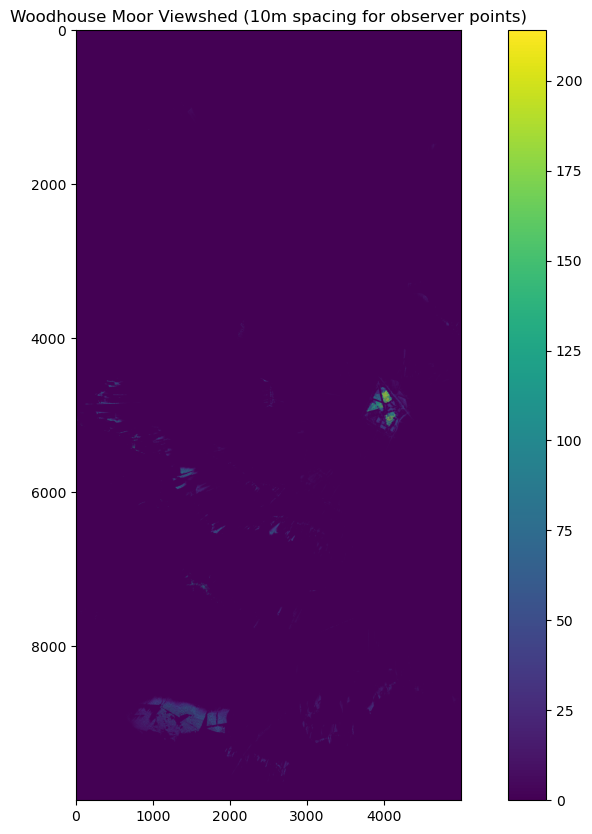

In [42]:
# Very basic plotting, to check that output dataset is as expected

data_name = "../qgis_work/final_diff_10m.tif"
tiff = rasterio.open(data_name)

fig, ax = plt.subplots(figsize=(12, 10))
plt.imshow(tiff.read(1), cmap='viridis')
ax.set_title("Woodhouse Moor Viewshed (10m spacing for observer points)")
plt.colorbar(ax.images[0], ax=ax)
plt.show()

In [43]:
# The TIFF is in British National Grid (LOCAL_CS defined, with bounds in BNG coordinates)
# The park is in EPSG:4326 (geographic, WGS84)
# We need to reproject the park to British National Grid (EPSG:27700)

# Reproject park to BNG (EPSG:27700)
park_gdf_bng = park_gdf.to_crs(epsg=27700)
print(f"Park reprojected to: {park_gdf_bng.crs}")
print(f"Park bounds in BNG: {park_gdf_bng.total_bounds}")

# Create a 5m buffer in the projected CRS
park_buffered_bng = park_gdf_bng.geometry.buffer(5)

# Convert to geojson format for rasterio.mask
shapes = [json.loads(gpd.GeoSeries(park_buffered_bng).to_json())['features'][0]['geometry']]

Park reprojected to: EPSG:27700
Park bounds in BNG: [428695.23831651 434725.59       429254.66       435422.8       ]


In [44]:
cropped_tiff, cropped_transform = mask(tiff, shapes, crop=True)

/Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


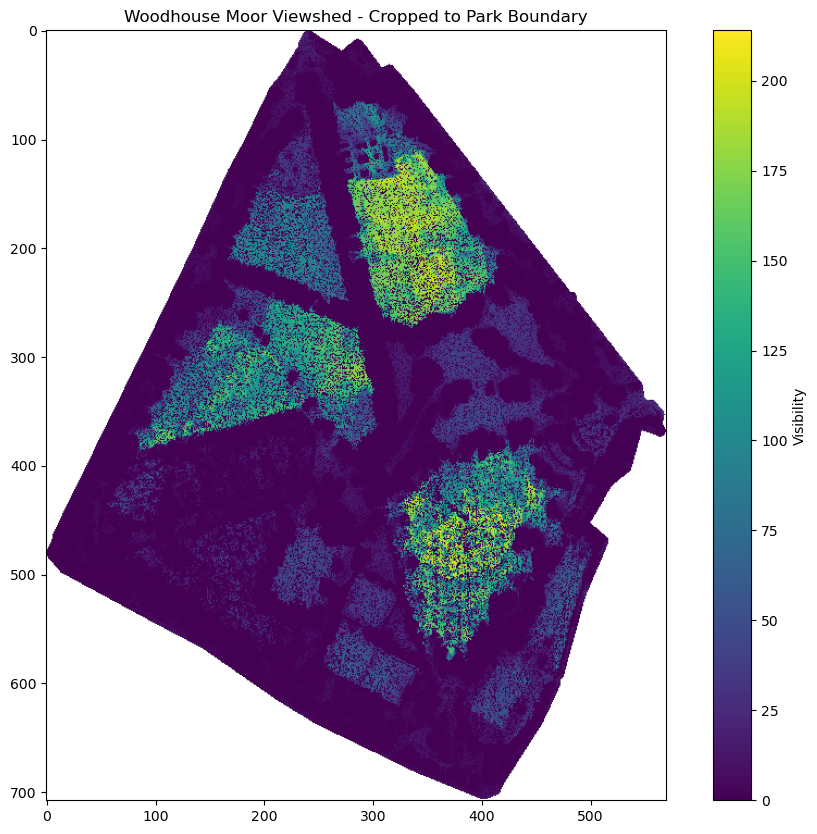

0.0 214.0


In [45]:
# Mask nodata values
# The huge negative value is the nodata value for float32
cropped_data = cropped_tiff[0].copy()
nodata_mask = cropped_data < -1e30  # Mask nodata values
cropped_data_masked = np.ma.masked_where(nodata_mask, cropped_data)

# Create metadata dict for the cropped, masked raster
cropped_meta = tiff.meta.copy()
cropped_meta.update({
    'width': cropped_tiff.shape[2],
    'height': cropped_tiff.shape[1],
    'transform': cropped_transform,
    'nodata': tiff.nodata
})

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cropped_data_masked, cmap='viridis')
ax.set_title("Woodhouse Moor Viewshed - Cropped to Park Boundary")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Visibility")
plt.show()

print(cropped_data_masked.min(), cropped_data_masked.max())


In [46]:
# First using the 100m max visibility, square grid

park_vga_old = gpd.read_file("../outputs/method_01/Woodhouse_Moor_10_m_grid_100m_vis.geojson")
park_vga_old.head()

# Ok, again I will have to convert the CRS
park_vga_bng = park_vga_old.to_crs(epsg=27700)

<Axes: >

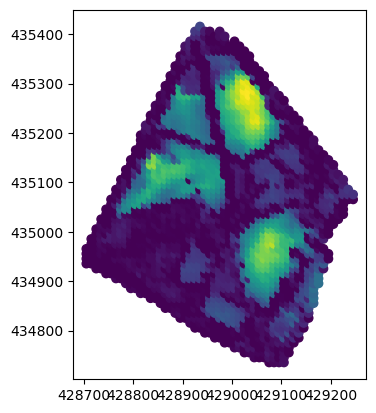

In [47]:
park_vga_bng.plot(column='visibility_pct')

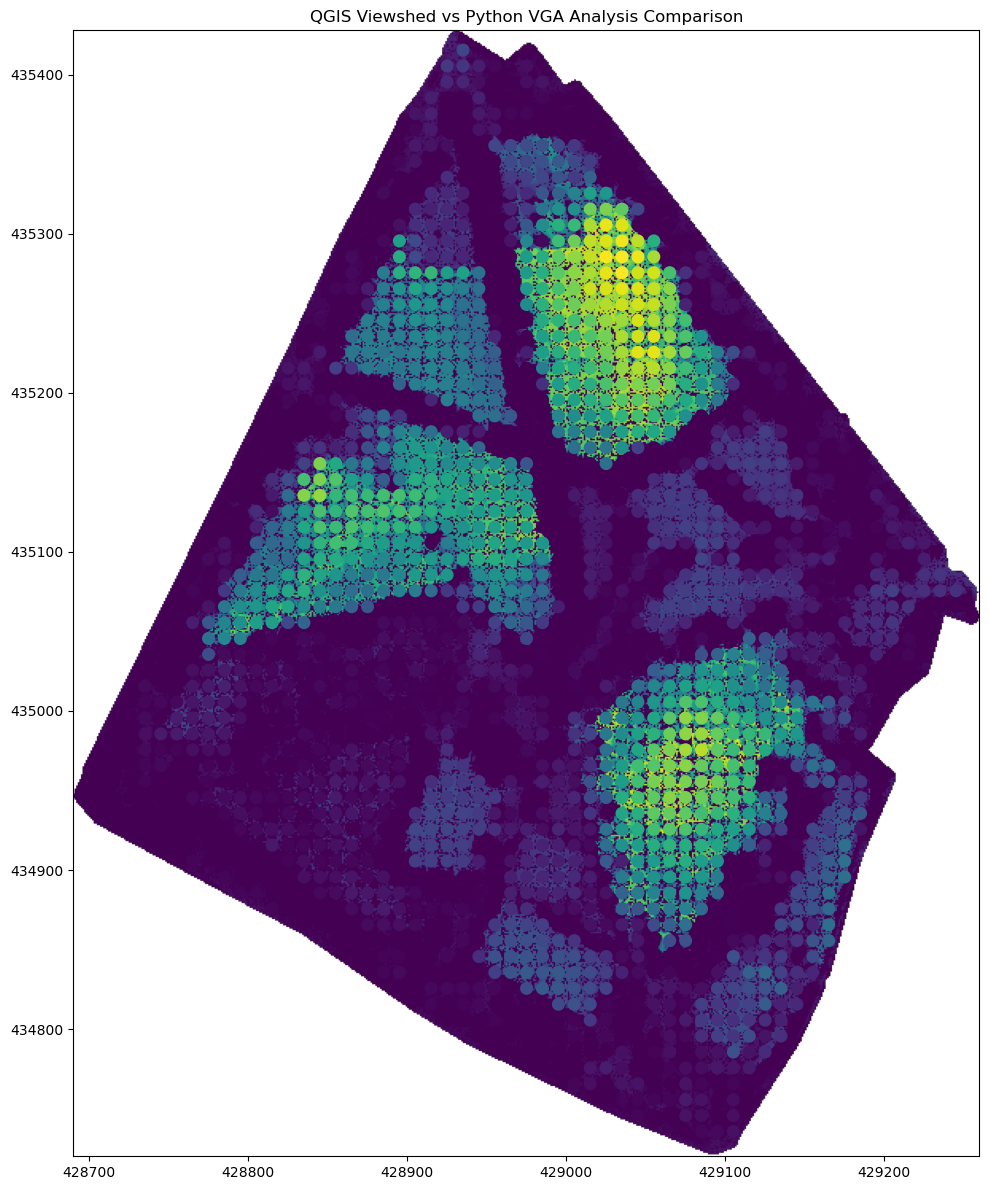

In [48]:
fig, ax = plt.subplots(figsize=(14, 12))

rasterio.plot.show(cropped_data_masked, transform=cropped_transform, ax=ax, cmap='viridis')

park_vga_bng.plot(column='visibility_pct', ax=ax, alpha=1, cmap='viridis', s=70)

ax.set_title("QGIS Viewshed vs Python VGA Analysis Comparison")
plt.tight_layout()
plt.show()

Before selecting points to compare with from the tiff, need to smooth and resample so we don't unintentionally amplify noisy pixels.

In [49]:
from scipy.ndimage import gaussian_filter

# Apply simple Gaussian smoothing to the full TIFF before cropping
full_tiff_data = tiff.read(1)
full_tiff_smoothed = gaussian_filter(full_tiff_data.astype(float), sigma=3)

print(f"Original data range: {np.nanmin(full_tiff_data):.2f} to {np.nanmax(full_tiff_data):.2f}")
print(f"Smoothed data range: {np.nanmin(full_tiff_smoothed):.2f} to {np.nanmax(full_tiff_smoothed):.2f}")

# Now crop the smoothed TIFF
from rasterio.mask import mask
from rasterio.io import MemoryFile
import rasterio

# Create a temporary in-memory raster from the smoothed data
with MemoryFile() as memfile:
    with memfile.open(**tiff.meta) as mem_dst:
        mem_dst.write(full_tiff_smoothed, 1)
        
        # Crop using the same shapes as before
        cropped_smoothed_tiff, cropped_transform = mask(mem_dst, shapes, crop=True)

# Mask nodata values in the cropped smoothed data
cropped_smoothed_data = cropped_smoothed_tiff[0]
nodata_mask_smoothed = cropped_smoothed_data < -1e10
tiff_smoothed = np.ma.masked_where(nodata_mask_smoothed, cropped_smoothed_data)

tiff_smoothed_transform = cropped_transform
tiff_smoothed_crs = tiff.crs


Original data range: 0.00 to 214.00
Smoothed data range: 0.00 to 159.52


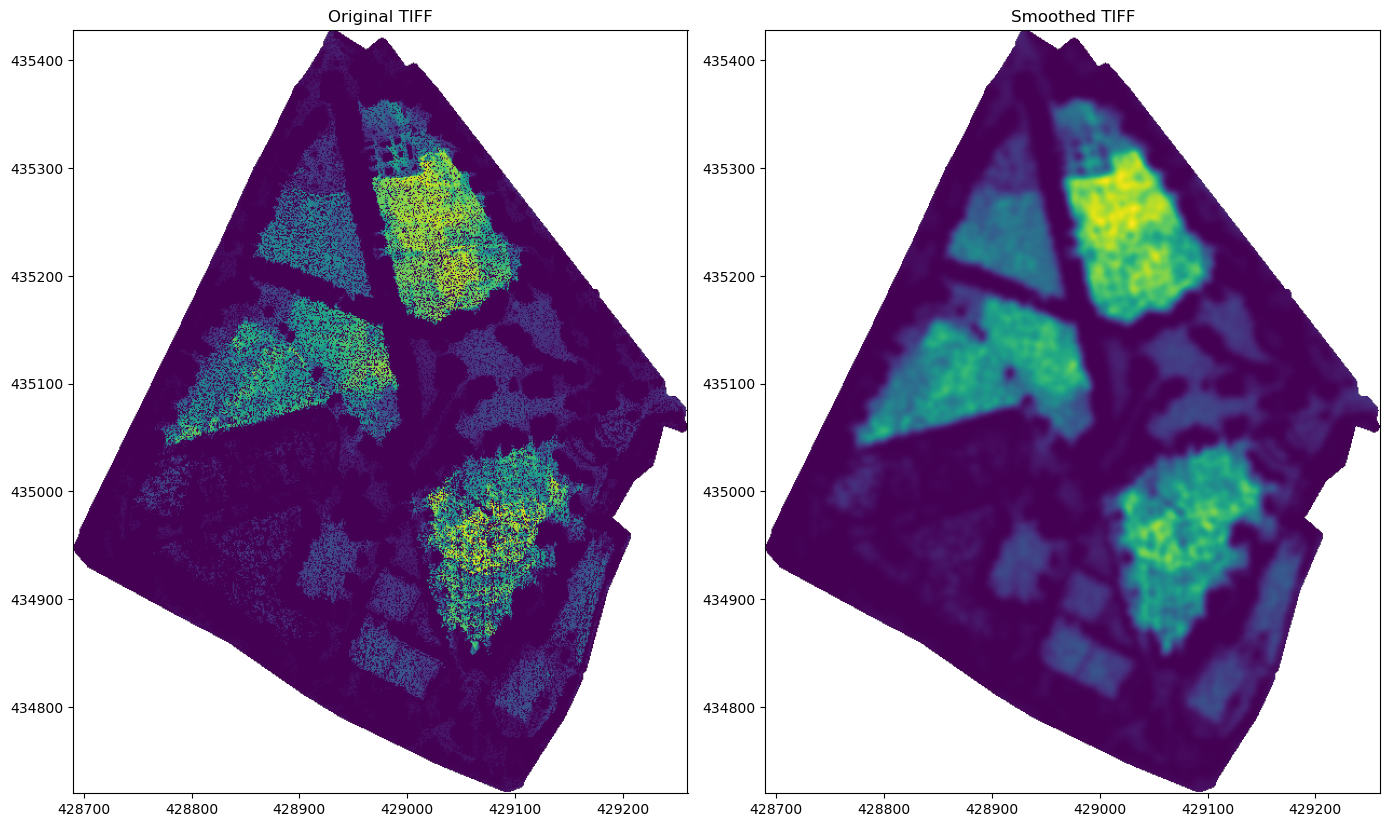

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(14, 10))

rasterio.plot.show(cropped_data_masked, transform=cropped_transform, ax=axs[0], cmap='viridis')
axs[0].set_title('Original TIFF')

rasterio.plot.show(tiff_smoothed, transform=cropped_transform, ax=axs[1], cmap='viridis')
axs[1].set_title('Smoothed TIFF')

plt.tight_layout()
plt.show()


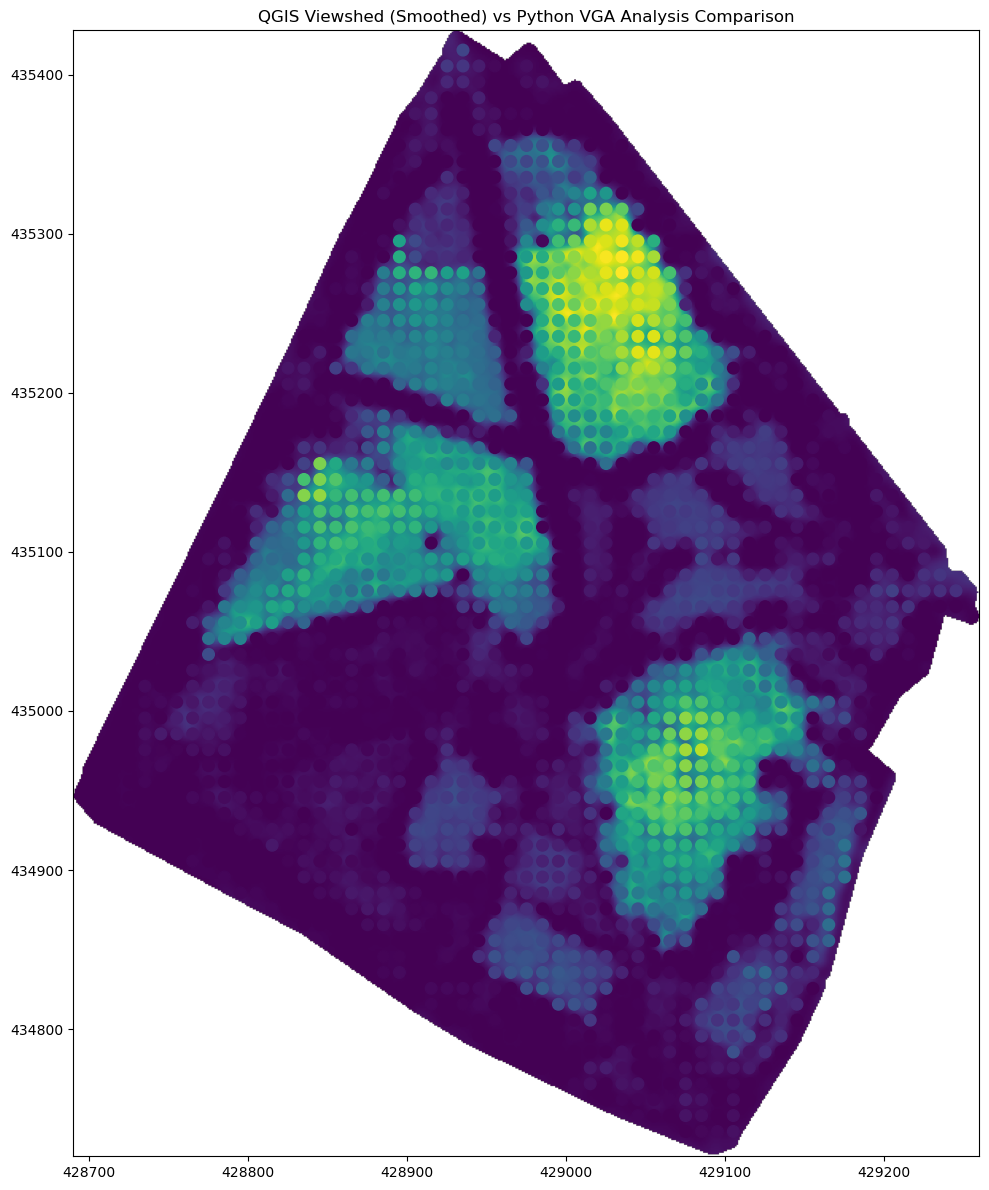

In [51]:
fig, ax = plt.subplots(figsize=(14, 12))

rasterio.plot.show(tiff_smoothed, transform=cropped_transform, ax=ax, cmap='viridis')

park_vga_bng.plot(column='visibility_pct', ax=ax, alpha=1, cmap='viridis', s=70)

ax.set_title("QGIS Viewshed (Smoothed) vs Python VGA Analysis Comparison")
plt.tight_layout()
plt.show()


In [52]:
# Sample smoothed TIFF at Python grid points (no resampling, original 10m resolution)
tiff_smoothed_values = []

# Get coordinates from Python grid points
coords = [(geom.x, geom.y) for geom in park_vga_bng.geometry]

for coord in coords:
    try:
        # Get row, col from coordinate using the cropped transform
        # Note: ~transform * (x, y) returns (col, row) not (row, col)
        col, row = ~tiff_smoothed_transform * coord
        row, col = int(row), int(col)
        
        # Check bounds
        if 0 <= row < tiff_smoothed.shape[0] and 0 <= col < tiff_smoothed.shape[1]:
            value = tiff_smoothed[row, col]
            # Check for nodata/masked values
            if tiff_smoothed.mask[row, col]:
                tiff_smoothed_values.append(np.nan)
            else:
                tiff_smoothed_values.append(float(value))
        else:
            tiff_smoothed_values.append(np.nan)
    except:
        tiff_smoothed_values.append(np.nan)

# Add sampled values to GeoDataFrame
park_vga_bng['tiff_smoothed'] = tiff_smoothed_values

# Summary statistics
valid_count = len([x for x in tiff_smoothed_values if not np.isnan(x)])
print(f"\nSmoothed TIFF Sampling Results (10m resolution):")
print(f"Sampled {valid_count} valid points from {len(coords)} grid points")
print(f"Mean value: {np.nanmean(tiff_smoothed_values):.2f}")
print(f"Min value: {np.nanmin(tiff_smoothed_values):.2f}")
print(f"Max value: {np.nanmax(tiff_smoothed_values):.2f}")
print(f"Std dev: {np.nanstd(tiff_smoothed_values):.2f}")

# Compare with Python VGA values
print(f"\nPython VGA Visibility Comparison:")
print(f"Python VGA mean: {park_vga_bng['visibility_pct'].mean():.2f}")
print(f"Python VGA std dev: {park_vga_bng['visibility_pct'].std():.2f}")



Smoothed TIFF Sampling Results (10m resolution):
Sampled 2185 valid points from 2185 grid points
Mean value: 27.16
Min value: 0.00
Max value: 154.42
Std dev: 37.63

Python VGA Visibility Comparison:
Python VGA mean: 9.07
Python VGA std dev: 12.06


In [53]:
# Diagnostic: Check transforms and coordinate systems
print("Transform diagnostic:")
print(f"park_vga_bng CRS: {park_vga_bng.crs}")
print(f"tiff_smoothed_transform: {tiff_smoothed_transform}")
print(f"cropped_transform: {cropped_transform}")
print(f"First point geometry: {park_vga_bng.geometry.iloc[0]}")
print(f"\nTesting coordinate transformation for first point:")
first_coord = (park_vga_bng.geometry.iloc[0].x, park_vga_bng.geometry.iloc[0].y)
print(f"Coordinate: {first_coord}")
row, col = ~tiff_smoothed_transform * first_coord
print(f"Pixel location (row, col): ({row}, {col})")
print(f"Smoothed TIFF shape: {tiff_smoothed.shape}")
print(f"Within bounds: {0 <= row < tiff_smoothed.shape[0] and 0 <= col < tiff_smoothed.shape[1]}")


Transform diagnostic:
park_vga_bng CRS: EPSG:27700
tiff_smoothed_transform: | 1.00, 0.00, 428690.00|
| 0.00,-1.00, 435428.00|
| 0.00, 0.00, 1.00|
cropped_transform: | 1.00, 0.00, 428690.00|
| 0.00,-1.00, 435428.00|
| 0.00, 0.00, 1.00|
First point geometry: POINT (428705.23831651127 434935.5900000001)

Testing coordinate transformation for first point:
Coordinate: (428705.23831651127, 434935.5900000001)
Pixel location (row, col): (15.238316511269659, 492.4099999999162)
Smoothed TIFF shape: (708, 570)
Within bounds: True


In [54]:
# Scale TIFF values to match Python VGA range for fair comparison
python_vga_min = park_vga_bng['visibility_pct'].min()
python_vga_max = park_vga_bng['visibility_pct'].max()

tiff_min = np.nanmin(tiff_smoothed_values)
tiff_max = np.nanmax(tiff_smoothed_values)

# Min-max normalization to scale TIFF to Python VGA range
tiff_scaled = np.array(tiff_smoothed_values)
valid_indices = ~np.isnan(tiff_scaled)
tiff_scaled[valid_indices] = (tiff_scaled[valid_indices] - tiff_min) / (tiff_max - tiff_min) * (python_vga_max - python_vga_min) + python_vga_min

park_vga_bng['tiff_scaled'] = tiff_scaled

print(f"TIFF original range: {tiff_min:.2f} to {tiff_max:.2f}")
print(f"Python VGA range: {python_vga_min:.2f} to {python_vga_max:.2f}")
print(f"TIFF scaled range: {np.nanmin(tiff_scaled):.2f} to {np.nanmax(tiff_scaled):.2f}")

# Calculate difference
park_vga_bng['difference'] = park_vga_bng['visibility_pct'] - park_vga_bng['tiff_scaled']

print(f"\nDifference statistics (Python - TIFF):")
print(f"Mean difference: {park_vga_bng['difference'].mean():.2f}")
print(f"Std dev: {park_vga_bng['difference'].std():.2f}")
print(f"Min: {park_vga_bng['difference'].min():.2f}")
print(f"Max: {park_vga_bng['difference'].max():.2f}")


TIFF original range: 0.00 to 154.42
Python VGA range: 0.00 to 48.03
TIFF scaled range: 0.00 to 48.03

Difference statistics (Python - TIFF):
Mean difference: 0.62
Std dev: 3.93
Min: -16.68
Max: 25.92


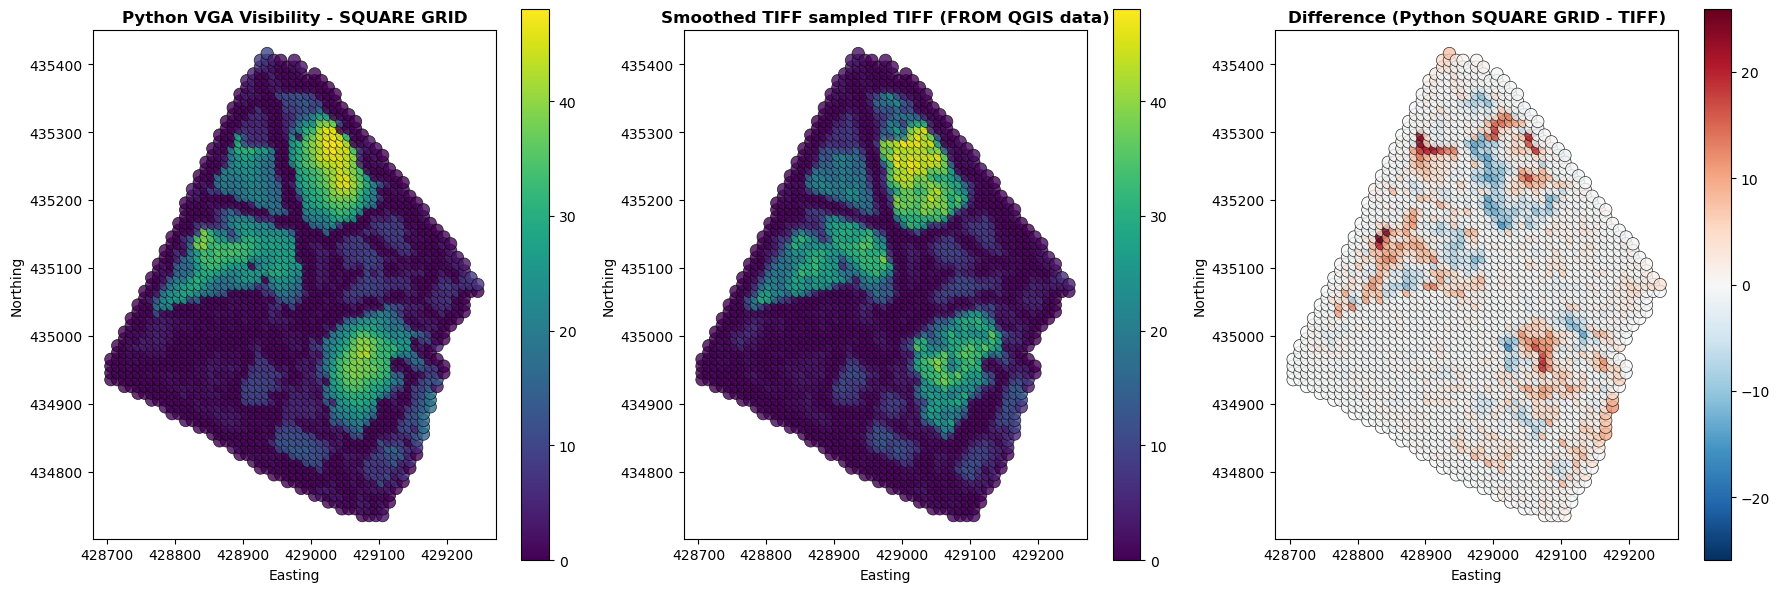

In [55]:
# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Python VGA
park_vga_bng.plot(column='visibility_pct', ax=axes[0], alpha=0.8, s=80,
                  cmap='viridis', edgecolor='black', linewidth=0.5, legend=True)
axes[0].set_title('Python VGA Visibility - SQUARE GRID', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Easting')
axes[0].set_ylabel('Northing')

# Plot 2: Scaled TIFF
park_vga_bng.plot(column='tiff_scaled', ax=axes[1], alpha=0.8, s=80,
                  cmap='viridis', edgecolor='black', linewidth=0.5, legend=True)
axes[1].set_title('Smoothed TIFF sampled TIFF (FROM QGIS data)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Easting')
axes[1].set_ylabel('Northing')

# Plot 3: Difference (Python VGA - Scaled TIFF)
# Use a diverging colormap centered on 0
park_vga_bng.plot(column='difference', ax=axes[2], alpha=0.8, s=80,
                  cmap='RdBu_r', edgecolor='black', linewidth=0.5, legend=True,
                  vmin=-park_vga_bng['difference'].abs().max(),
                  vmax=park_vga_bng['difference'].abs().max())
axes[2].set_title('Difference (Python SQUARE GRID - TIFF)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Easting')
axes[2].set_ylabel('Northing')

plt.tight_layout()
plt.show()


## Statistical Comparison: Scatter Plot and Correlation

Scatter plot showing relationship between Python VGA and smoothed TIFF values across all grid points. Points close to the 1:1 line indicate good agreement between methods.


Correlation Analysis:
  Pearson r: 0.9458
  p-value: 0.00e+00
  RMSE: 3.9748
  MAE: 2.2670


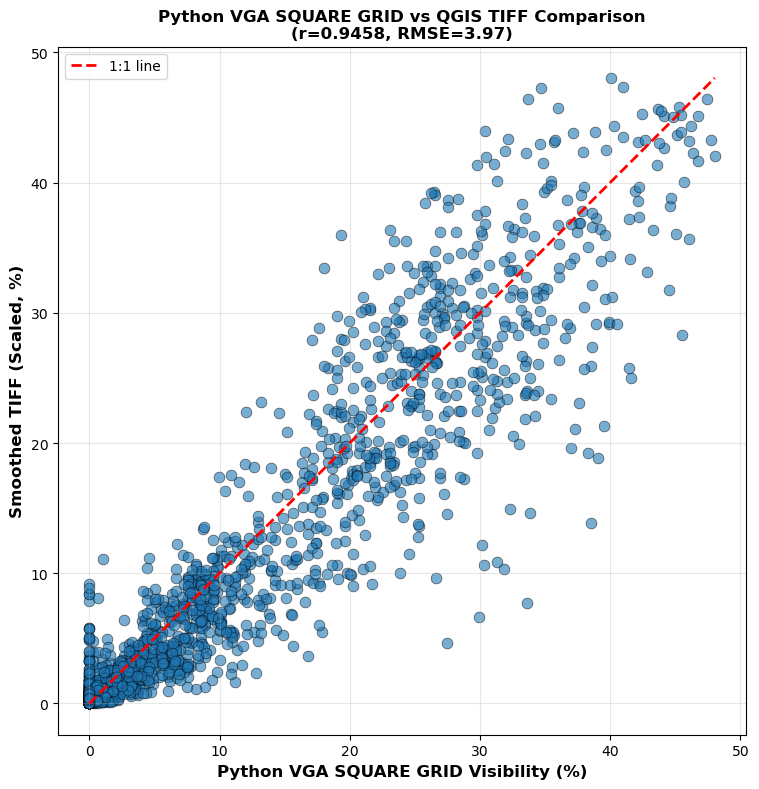

In [56]:


# Remove NaN values for correlation calculation
valid_mask = ~(np.isnan(park_vga_bng['visibility_pct']) | np.isnan(park_vga_bng['tiff_scaled']))
python_vga_valid = park_vga_bng.loc[valid_mask, 'visibility_pct'].values
tiff_scaled_valid = park_vga_bng.loc[valid_mask, 'tiff_scaled'].values

# Calculate correlation and RMSE
correlation, pvalue = pearsonr(python_vga_valid, tiff_scaled_valid)
rmse = np.sqrt(np.mean((python_vga_valid - tiff_scaled_valid) ** 2))
mae = np.mean(np.abs(python_vga_valid - tiff_scaled_valid))

print(f"Correlation Analysis:")
print(f"  Pearson r: {correlation:.4f}")
print(f"  p-value: {pvalue:.2e}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(python_vga_valid, tiff_scaled_valid, alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
min_val = min(python_vga_valid.min(), tiff_scaled_valid.min())
max_val = max(python_vga_valid.max(), tiff_scaled_valid.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')

# Labels and formatting
ax.set_xlabel('Python VGA SQUARE GRID Visibility (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Smoothed TIFF (Scaled, %)', fontsize=12, fontweight='bold')
ax.set_title(f'Python VGA SQUARE GRID vs QGIS TIFF Comparison\n(r={correlation:.4f}, RMSE={rmse:.2f})', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


Immediate improvement, because target height now matches across both models (e.g. 0m).


## The hex grid comparison

Now comparing this to the hex-grid option

In [57]:
# the new hex grid option

park_vga_old = gpd.read_file("../outputs/method_02_hex/Woodhouse_Moor_10_m_grid_100m_vis_hex.geojson")
park_vga_old.head()

# Ok, again I will have to convert the CRS
park_vga_bng = park_vga_old.to_crs(epsg=27700)

<Axes: >

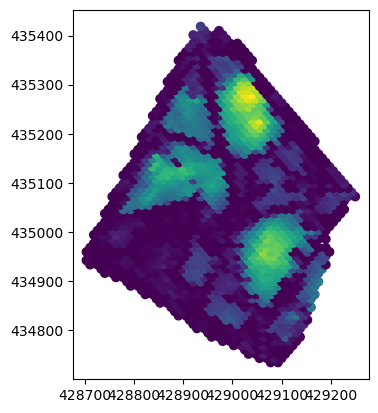

In [58]:
park_vga_bng.plot(column='visibility_pct')

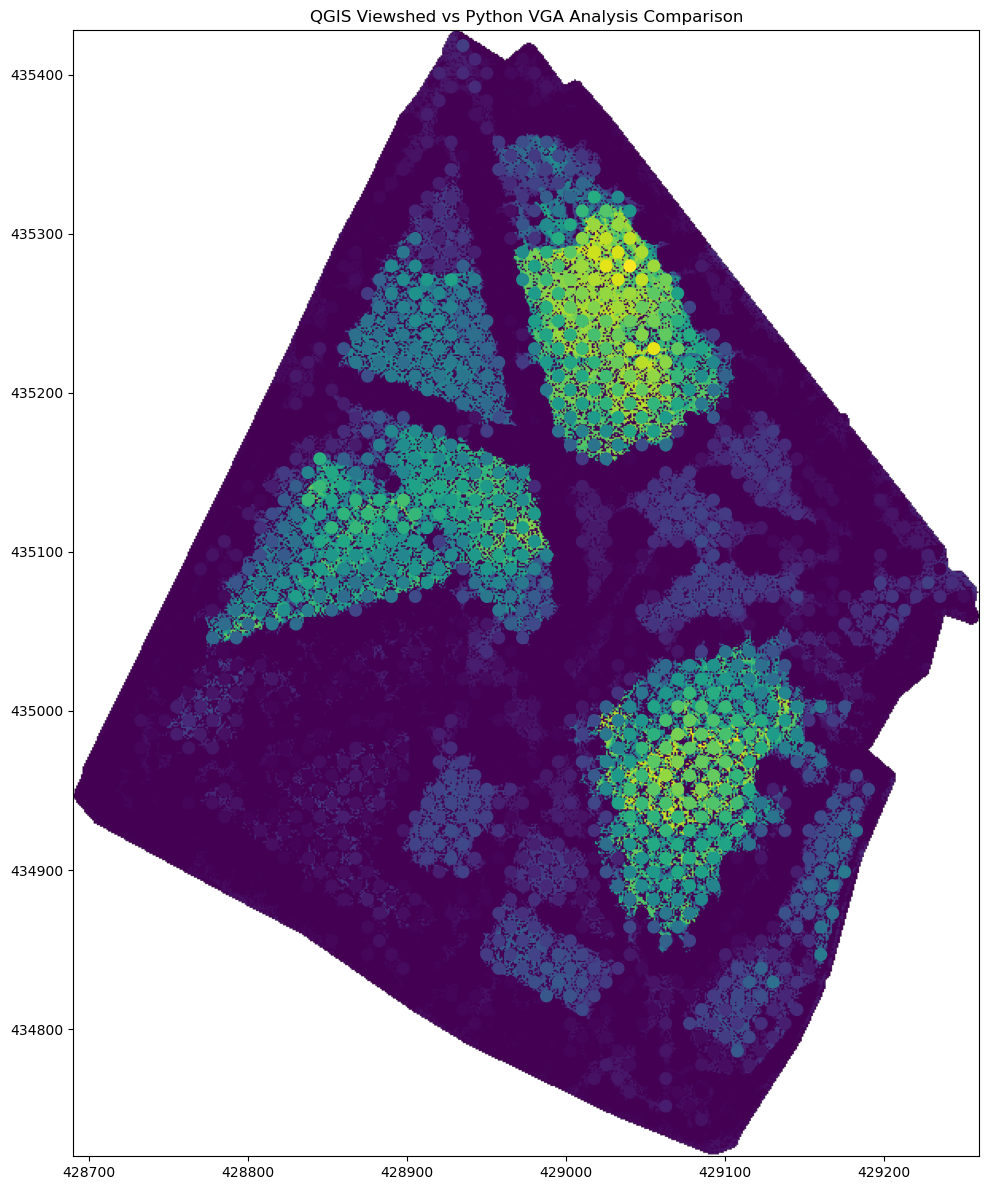

In [59]:
fig, ax = plt.subplots(figsize=(14, 12))

rasterio.plot.show(cropped_data_masked, transform=cropped_transform, ax=ax, cmap='viridis')

park_vga_bng.plot(column='visibility_pct', ax=ax, alpha=1, cmap='viridis', s=70)

ax.set_title("QGIS Viewshed vs Python VGA Analysis Comparison")
plt.tight_layout()
plt.show()

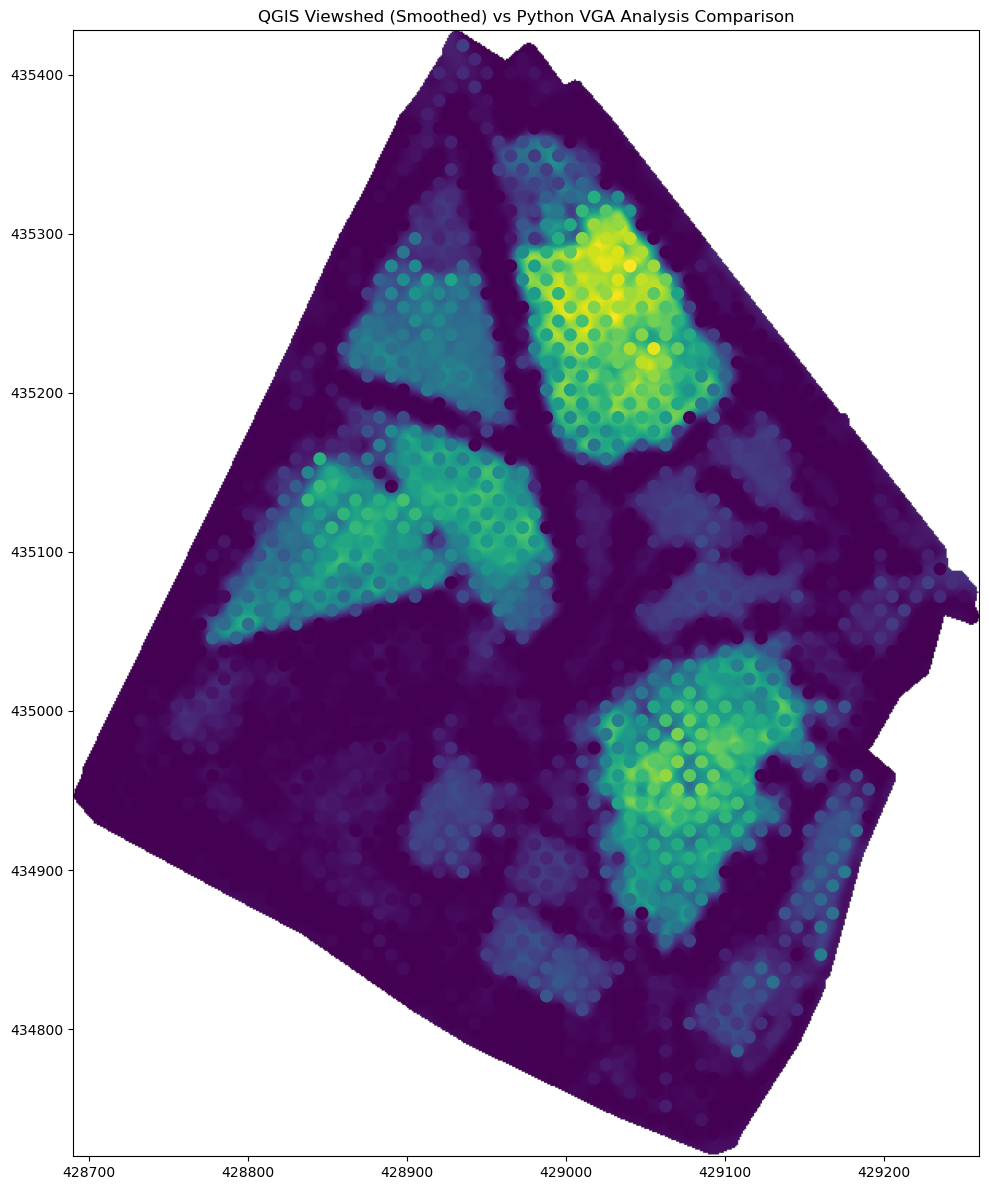

In [60]:
fig, ax = plt.subplots(figsize=(14, 12))

rasterio.plot.show(tiff_smoothed, transform=cropped_transform, ax=ax, cmap='viridis')

park_vga_bng.plot(column='visibility_pct', ax=ax, alpha=1, cmap='viridis', s=70)

ax.set_title("QGIS Viewshed (Smoothed) vs Python VGA Analysis Comparison")
plt.tight_layout()
plt.show()

In [61]:
# get the qgis dataset values at the hex grid points

# Sample smoothed TIFF at Python grid points (no resampling, original 10m resolution)
tiff_smoothed_values = []

# Get coordinates from Python grid points
coords = [(geom.x, geom.y) for geom in park_vga_bng.geometry]

for coord in coords:
    try:
        # Get row, col from coordinate using the cropped transform
        # Note: ~transform * (x, y) returns (col, row) not (row, col)
        col, row = ~tiff_smoothed_transform * coord
        row, col = int(row), int(col)
        
        # Check bounds
        if 0 <= row < tiff_smoothed.shape[0] and 0 <= col < tiff_smoothed.shape[1]:
            value = tiff_smoothed[row, col]
            # Check for nodata/masked values
            if tiff_smoothed.mask[row, col]:
                tiff_smoothed_values.append(np.nan)
            else:
                tiff_smoothed_values.append(float(value))
        else:
            tiff_smoothed_values.append(np.nan)
    except:
        tiff_smoothed_values.append(np.nan)

# Add sampled values to GeoDataFrame
park_vga_bng['tiff_smoothed'] = tiff_smoothed_values

# Summary statistics
valid_count = len([x for x in tiff_smoothed_values if not np.isnan(x)])
print(f"\nSmoothed TIFF Sampling Results (10m resolution):")
print(f"Sampled {valid_count} valid points from {len(coords)} grid points")
print(f"Mean value: {np.nanmean(tiff_smoothed_values):.2f}")
print(f"Min value: {np.nanmin(tiff_smoothed_values):.2f}")
print(f"Max value: {np.nanmax(tiff_smoothed_values):.2f}")
print(f"Std dev: {np.nanstd(tiff_smoothed_values):.2f}")

# Compare with Python VGA values
print(f"\nPython VGA Visibility Comparison:")
print(f"Python VGA mean: {park_vga_bng['visibility_pct'].mean():.2f}")
print(f"Python VGA std dev: {park_vga_bng['visibility_pct'].std():.2f}")



Smoothed TIFF Sampling Results (10m resolution):
Sampled 1685 valid points from 1685 grid points
Mean value: 27.08
Min value: 0.00
Max value: 154.86
Std dev: 37.57

Python VGA Visibility Comparison:
Python VGA mean: 8.66
Python VGA std dev: 11.53


In [62]:
# Scale TIFF values to match Python VGA range for fair comparison
python_vga_min = park_vga_bng['visibility_pct'].min()
python_vga_max = park_vga_bng['visibility_pct'].max()

tiff_min = np.nanmin(tiff_smoothed_values)
tiff_max = np.nanmax(tiff_smoothed_values)

# Min-max normalization to scale TIFF to Python VGA range
tiff_scaled = np.array(tiff_smoothed_values)
valid_indices = ~np.isnan(tiff_scaled)
tiff_scaled[valid_indices] = (tiff_scaled[valid_indices] - tiff_min) / (tiff_max - tiff_min) * (python_vga_max - python_vga_min) + python_vga_min

park_vga_bng['tiff_scaled'] = tiff_scaled

print(f"TIFF original range: {tiff_min:.2f} to {tiff_max:.2f}")
print(f"Python VGA range: {python_vga_min:.2f} to {python_vga_max:.2f}")
print(f"TIFF scaled range: {np.nanmin(tiff_scaled):.2f} to {np.nanmax(tiff_scaled):.2f}")

# Calculate difference
park_vga_bng['difference'] = park_vga_bng['visibility_pct'] - park_vga_bng['tiff_scaled']

print(f"\nDifference statistics (Python - TIFF):")
print(f"Mean difference: {park_vga_bng['difference'].mean():.2f}")
print(f"Std dev: {park_vga_bng['difference'].std():.2f}")
print(f"Min: {park_vga_bng['difference'].min():.2f}")
print(f"Max: {park_vga_bng['difference'].max():.2f}")

TIFF original range: 0.00 to 154.86
Python VGA range: 0.00 to 48.62
TIFF scaled range: 0.00 to 48.62

Difference statistics (Python - TIFF):
Mean difference: 0.16
Std dev: 3.75
Min: -19.34
Max: 23.13


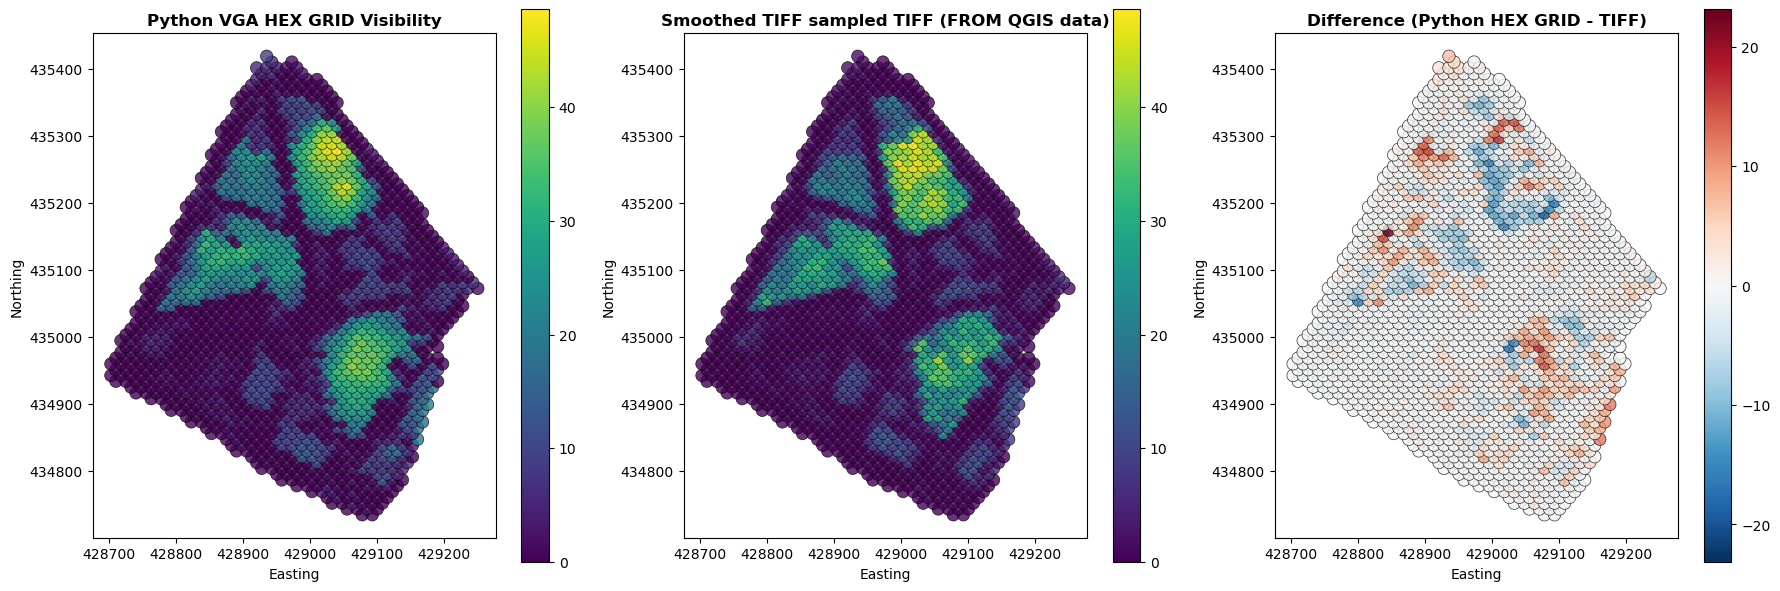

In [63]:
# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Python VGA
park_vga_bng.plot(column='visibility_pct', ax=axes[0], alpha=0.8, s=80,
                  cmap='viridis', edgecolor='black', linewidth=0.5, legend=True)
axes[0].set_title('Python VGA HEX GRID Visibility', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Easting')
axes[0].set_ylabel('Northing')

# Plot 2: Scaled TIFF
park_vga_bng.plot(column='tiff_scaled', ax=axes[1], alpha=0.8, s=80,
                  cmap='viridis', edgecolor='black', linewidth=0.5, legend=True)
axes[1].set_title('Smoothed TIFF sampled TIFF (FROM QGIS data)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Easting')
axes[1].set_ylabel('Northing')

# Plot 3: Difference (Python VGA - Scaled TIFF)
# Use a diverging colormap centered on 0
park_vga_bng.plot(column='difference', ax=axes[2], alpha=0.8, s=80,
                  cmap='RdBu_r', edgecolor='black', linewidth=0.5, legend=True,
                  vmin=-park_vga_bng['difference'].abs().max(),
                  vmax=park_vga_bng['difference'].abs().max())
axes[2].set_title('Difference (Python HEX GRID - TIFF)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Easting')
axes[2].set_ylabel('Northing')

plt.tight_layout()
plt.show()


Correlation Analysis:
  Pearson r: 0.9487
  p-value: 0.00e+00
  RMSE: 3.7482
  MAE: 2.2081


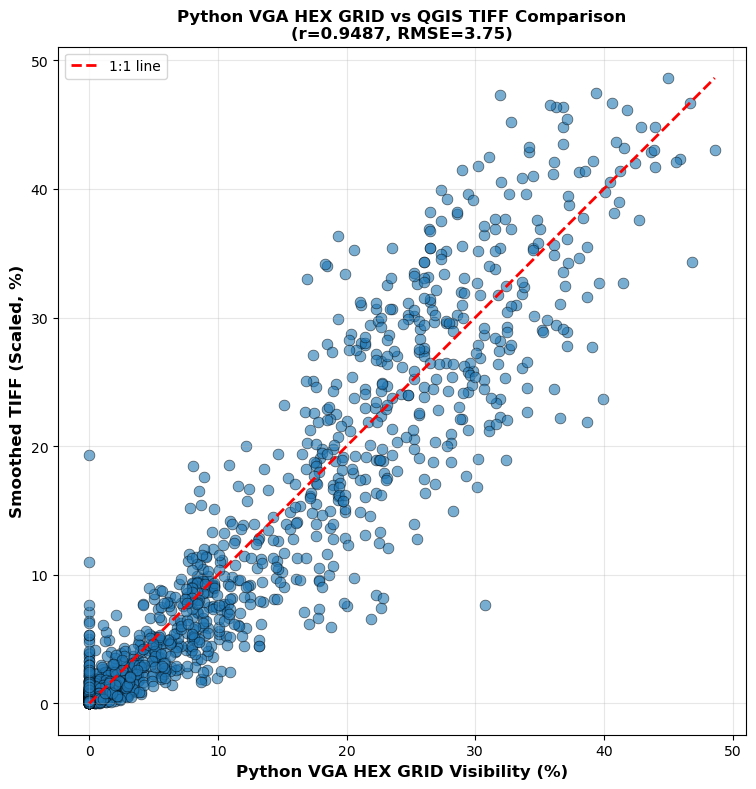

In [64]:
# Remove NaN values for correlation calculation
valid_mask = ~(np.isnan(park_vga_bng['visibility_pct']) | np.isnan(park_vga_bng['tiff_scaled']))
python_vga_valid = park_vga_bng.loc[valid_mask, 'visibility_pct'].values
tiff_scaled_valid = park_vga_bng.loc[valid_mask, 'tiff_scaled'].values

# Calculate correlation and RMSE
correlation, pvalue = pearsonr(python_vga_valid, tiff_scaled_valid)
rmse = np.sqrt(np.mean((python_vga_valid - tiff_scaled_valid) ** 2))
mae = np.mean(np.abs(python_vga_valid - tiff_scaled_valid))

print(f"Correlation Analysis:")
print(f"  Pearson r: {correlation:.4f}")
print(f"  p-value: {pvalue:.2e}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(python_vga_valid, tiff_scaled_valid, alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
min_val = min(python_vga_valid.min(), tiff_scaled_valid.min())
max_val = max(python_vga_valid.max(), tiff_scaled_valid.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 line')

# Labels and formatting
ax.set_xlabel('Python VGA HEX GRID Visibility (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Smoothed TIFF (Scaled, %)', fontsize=12, fontweight='bold')
ax.set_title(f'Python VGA HEX GRID vs QGIS TIFF Comparison\n(r={correlation:.4f}, RMSE={rmse:.2f})', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

Ok, so the hex grid returns almost identical results, with a difference in r value of 0.0029, essentially neglible. The RMSE difference is 0.22; when looking at a visibility scale of 0-100%, this is essentially equivalent to a difference of 0.2% visibility, so again equal for our purposes.

But, the hex grid runs much faster due to the vastly reduced number of points; for this example it required 23% fewer points for the same results.

Also, if you look at the heatmap comparisons of where the differences arise, the hex grid produces fewer sharp artifacts near corners etc.

## How to visualise the hex grid

On the current dashboard, we show this map as a scatter plot with coloured points as per above; see the folder `visualisation_options` for osme work exploring the different ways to represent this on the map.